# Diamonds dataset

The idea is to predict:
- For classification: Cut (There are only 5 clasess)
- For regression: Price

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "data/raw/diamonds.csv"
exit_path = "data/eda/diamonds.csv"

In [3]:
df = pd.read_csv(file_path, dtype=str, index_col=0)
print(f"Dimensiones del ds {df.shape}")

Dimensiones del ds (53940, 10)


In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58,334,4.2,4.23,2.63
5,0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75


In [5]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [6]:
df.describe()

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940,53940,53940,53940,53940,53940,53940,53940,53940,53940
unique,273,5,7,8,184,127,11602,554,552,375
top,0.3,Ideal,G,SI1,62,56,605,4.37,4.34,2.7
freq,2604,21551,11292,13065,2239,9881,132,448,437,767


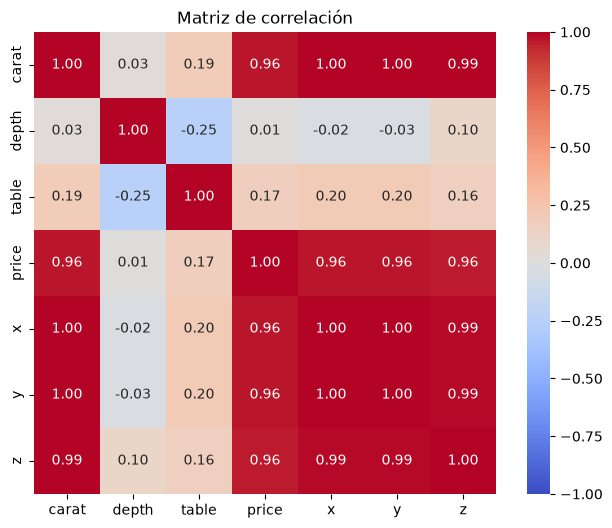

In [7]:
cols_num = ["carat", "depth", "table", "price", "x", "y", "z"]
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors="coerce")
corr = df[cols_num].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación")
plt.show()

In [8]:
print(f"Minimo: {df["price"].min()}")
print(f"Minimo: {df["price"].max()}")

Minimo: 326
Minimo: 18823


In [9]:
df["cut"].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

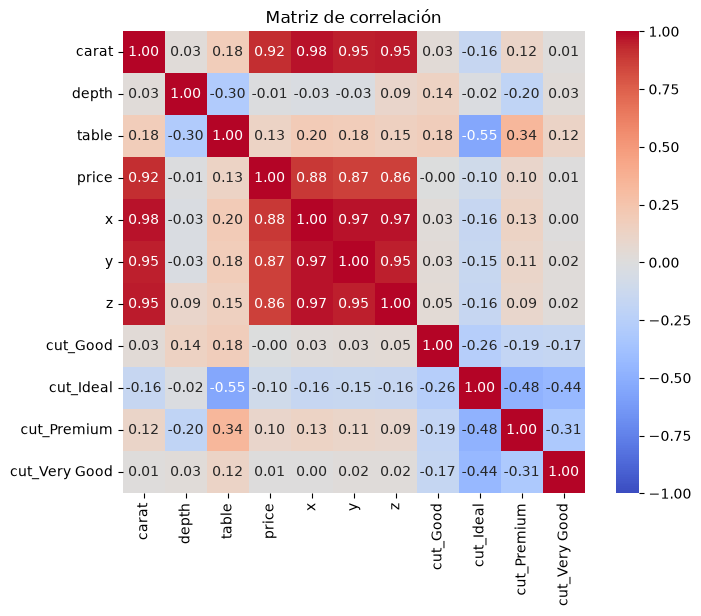

In [10]:
cat_features = ['cut']
num_features = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

df_encoded = pd.get_dummies(df[num_features + cat_features],
                             columns=cat_features, drop_first=True)

corr_matrix = df_encoded.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación")
plt.show()

In [11]:
# To do: corresponding eda

In [12]:
df.to_csv(exit_path, index=False)